# TASK 1: Import and Inspect the Dataset

In [2]:
file_name <- "/content/PRSA_Data_Aotizhongxin_20130301-20170228.csv"

air_quality <- tryCatch({

  data <- read.csv(file_name, stringsAsFactors = FALSE)

  if (ncol(data) <= 1) {
    stop("File format appears to be incorrect.")
  }

  cat("Dataset imported successfully.\n")
  data

}, error = function(e) {

  cat("Error while importing dataset:", e$message, "\n")
  NULL

})

if (!is.null(air_quality)) {

  cat("\nFirst six records:\n")
  print(head(air_quality))

  cat("\nStructure of Dataset:\n")
  str(air_quality)

  cat("\nNumber of Rows:", nrow(air_quality), "\n")
  cat("Number of Columns:", ncol(air_quality), "\n")

  cat("\nDataset contains missing values:",
      any(is.na(air_quality)), "\n")

  cat("Total Missing Values:",
      sum(is.na(air_quality)), "\n")
}

Dataset imported successfully.

First six records:
  No year month day hour PM2.5 PM10 SO2 NO2  CO O3 TEMP   PRES  DEWP RAIN  wd
1  1 2013     3   1    0     4    4   4   7 300 77 -0.7 1023.0 -18.8    0 NNW
2  2 2013     3   1    1     8    8   4   7 300 77 -1.1 1023.2 -18.2    0   N
3  3 2013     3   1    2     7    7   5  10 300 73 -1.1 1023.5 -18.2    0 NNW
4  4 2013     3   1    3     6    6  11  11 300 72 -1.4 1024.5 -19.4    0  NW
5  5 2013     3   1    4     3    3  12  12 300 72 -2.0 1025.2 -19.5    0   N
6  6 2013     3   1    5     5    5  18  18 400 66 -2.2 1025.6 -19.6    0   N
  WSPM      station
1  4.4 Aotizhongxin
2  4.7 Aotizhongxin
3  5.6 Aotizhongxin
4  3.1 Aotizhongxin
5  2.0 Aotizhongxin
6  3.7 Aotizhongxin

Structure of Dataset:
'data.frame':	35064 obs. of  18 variables:
 $ No     : int  1 2 3 4 5 6 7 8 9 10 ...
 $ year   : int  2013 2013 2013 2013 2013 2013 2013 2013 2013 2013 ...
 $ month  : int  3 3 3 3 3 3 3 3 3 3 ...
 $ day    : int  1 1 1 1 1 1 1 1 1 1 ...
 $

# TASK 2: Understanding NA, NULL and NaN

In [3]:
temperature <- c(28, 30, NA, 32)
missing_object <- NULL
undefined_value <- 0 / 0

cat("NA Example:\n")
print(temperature)
print(is.na(temperature))

cat("\nNULL Example:\n")
print(missing_object)
print(is.null(missing_object))

cat("\nNaN Example:\n")
print(undefined_value)
print(is.nan(undefined_value))

NA Example:
[1] 28 30 NA 32
[1] FALSE FALSE  TRUE FALSE

NULL Example:
NULL
[1] TRUE

NaN Example:
[1] NaN
[1] TRUE


# TASK 3: Missing Value Summary Function

In [4]:
selected_variables <- c(
  "PM2.5", "PM10", "SO2", "NO2",
  "TEMP", "WSPM", "wd"
)

missing_summary <- function(data) {

  result <- data.frame(
    Variable = character(),
    Total_Records = integer(),
    Missing_Values = integer(),
    Missing_Percentage = numeric(),
    stringsAsFactors = FALSE
  )

  for (variable in selected_variables) {

    if (!(variable %in% names(data))) {
      warning(paste("Variable", variable, "does not exist."))
      next
    }

    total <- nrow(data)
    missing <- sum(is.na(data[[variable]]))
    percentage <- (missing / total) * 100

    if (percentage > 20) {
      warning(
        paste(variable,
              "contains more than 20% missing values.")
      )
    }

    result <- rbind(
      result,
      data.frame(
        Variable = variable,
        Total_Records = total,
        Missing_Values = missing,
        Missing_Percentage = round(percentage, 2)
      )
    )
  }

  return(result)
}

summary_table <- missing_summary(air_quality)

print(summary_table)

  Variable Total_Records Missing_Values Missing_Percentage
1    PM2.5         35064            925               2.64
2     PM10         35064            718               2.05
3      SO2         35064            935               2.67
4      NO2         35064           1023               2.92
5     TEMP         35064             20               0.06
6     WSPM         35064             14               0.04
7       wd         35064             81               0.23


In [6]:
write.csv(
  summary_table,
  "/content/missing_summary.csv",
  row.names = FALSE
)

cat("Missing summary saved successfully.")

Missing summary saved successfully.

In [5]:
# Store missing values before cleaning

missing_before <- sapply(
  air_quality[selected_variables],
  function(x) sum(is.na(x))
)

print(missing_before)

PM2.5  PM10   SO2   NO2  TEMP  WSPM    wd 
  925   718   935  1023    20    14    81 


# TASK 4: Identify Invalid Numerical Results

In [7]:
air_quality$pollution_ratio <-
  air_quality$PM2.5 / air_quality$PM10

cat("NA values:",
    sum(is.na(air_quality$pollution_ratio)), "\n")

cat("NaN values:",
    sum(is.nan(air_quality$pollution_ratio)), "\n")

cat("Positive Infinity:",
    sum(air_quality$pollution_ratio == Inf,
        na.rm = TRUE), "\n")

cat("Negative Infinity:",
    sum(air_quality$pollution_ratio == -Inf,
        na.rm = TRUE), "\n")

# Replace NaN and infinite values with NA

invalid_values <-
  is.nan(air_quality$pollution_ratio) |
  is.infinite(air_quality$pollution_ratio)

air_quality$pollution_ratio[invalid_values] <- NA

cat("\nInvalid NaN/Infinite values replaced with NA:",
    sum(invalid_values), "\n")

NA values: 934 
NaN values: 0 
Positive Infinity: 0 
Negative Infinity: 0 

Invalid NaN/Infinite values replaced with NA: 0 


# TASK 5: Handle Missing Numerical Values Using a Loop

In [8]:
numeric_variables <- c(
  "PM2.5", "PM10", "SO2",
  "NO2", "TEMP", "WSPM"
)

for (variable in numeric_variables) {

  if (!(variable %in% names(air_quality))) {

    cat("Variable", variable, "does not exist.\n")
    next

  }

  missing_count_before <-
    sum(is.na(air_quality[[variable]]))

  median_value <-
    median(air_quality[[variable]], na.rm = TRUE)

  air_quality[[variable]][
    is.na(air_quality[[variable]])
  ] <- median_value

  missing_count_after <-
    sum(is.na(air_quality[[variable]]))

  cat("\nVariable:", variable, "\n")
  cat("Missing values before:",
      missing_count_before, "\n")
  cat("Median used:",
      median_value, "\n")
  cat("Missing values after:",
      missing_count_after, "\n")
}


Variable: PM2.5 
Missing values before: 925 
Median used: 58 
Missing values after: 0 

Variable: PM10 
Missing values before: 718 
Median used: 87 
Missing values after: 0 

Variable: SO2 
Missing values before: 935 
Median used: 9 
Missing values after: 0 

Variable: NO2 
Missing values before: 1023 
Median used: 53 
Missing values after: 0 

Variable: TEMP 
Missing values before: 20 
Median used: 14.5 
Missing values after: 0 

Variable: WSPM 
Missing values before: 14 
Median used: 1.4 
Missing values after: 0 


# TASK 6: Handle Missing Categorical Values

In [ ]:
calculate_mode <- function(x) {

  x <- x[!is.na(x)]

  if (length(x) == 0) {
    return(NA)
  }

  unique_values <- unique(x)

  frequencies <- tabulate(
    match(x, unique_values)
  )

  return(unique_values[which.max(frequencies)])
}

wd_missing_before <- sum(is.na(air_quality$wd))

wd_mode <- calculate_mode(air_quality$wd)

cat("Mode of wd:", wd_mode, "\n")
cat("Missing wd values before:",
    wd_missing_before, "\n")

air_quality$wd[
  is.na(air_quality$wd)
] <- wd_mode

wd_missing_after <- sum(is.na(air_quality$wd))

cat("Missing wd values after:",
    wd_missing_after, "\n")

# TASK 7: Error Handling using clean_variable()

In [9]:
clean_variable <- function(data, variable_name) {

  tryCatch({

    # Check whether variable exists
    if (!(variable_name %in% names(data))) {
      stop(
        paste("Variable", variable_name, "does not exist.")
      )
    }

    variable <- data[[variable_name]]

    # Check whether numerical
    if (!is.numeric(variable)) {
      stop(
        paste(variable_name,
              "is not a numerical variable.")
      )
    }

    # Check if all values are missing
    if (all(is.na(variable))) {
      stop(
        paste(variable_name,
              "contains only missing values.")
      )
    }

    median_value <- median(variable, na.rm = TRUE)

    # Check whether median is valid
    if (is.na(median_value) || is.nan(median_value)) {
      stop(
        paste("Median cannot be calculated for",
              variable_name)
      )
    }

    variable[is.na(variable)] <- median_value

    cat(
      variable_name,
      "cleaned successfully using median:",
      median_value,
      "\n"
    )

    return(variable)

  }, error = function(e) {

    cat("Error:", e$message, "\n")
    return(NULL)

  })
}

In [10]:
# Test 1 - Correct numerical variable
clean_variable(air_quality, "PM2.5")

# Test 2 - Categorical variable
clean_variable(air_quality, "wd")

# Test 3 - Variable that does not exist
clean_variable(air_quality, "ABC")

PM2.5 cleaned successfully using median: 58 


[1]   4.0   8.0   7.0   6.0   3.0   5.0   3.0   3.0   3.0   3.0   3.0   3.0
   [13]   3.0   3.0   6.0   8.0   9.0  10.0  11.0   8.0  11.0  12.0  15.0  24.0
   [25]  22.0  14.0  13.0   3.0   3.0   9.0   4.0   3.0   3.0  10.0  11.0  18.0
   [37]  26.0  25.0  26.0  37.0  37.0  44.0  54.0  61.0  67.0  74.0  81.0  93.0
   [49] 112.0 109.0 110.0 105.0 106.0 101.0  91.0  79.0  77.0  83.0  94.0  96.0
   [61]  91.0  98.0  72.0  48.0  28.0  26.0  24.0  19.0  60.0 117.0  54.0  46.0
   [73]  42.0  49.0  34.0  12.0   7.0  10.0  13.0  14.0  13.0  15.0  16.0  18.0
   [85]  13.0   3.0   3.0  10.0  14.0  20.0  25.0  31.0  34.0  40.0  51.0  58.0
   [97]  71.0  91.0 100.0 103.0 115.0 117.0 104.0 106.0 111.0 114.0 131.0 138.0
  [109] 142.0 163.0 168.0 165.0 166.0 190.0 203.0 210.0 205.0 215.0 219.0 226.0
  [121] 284.0 272.0 242.0 212.0 192.0 188.0 186.0 188.0 194.0 184.0 175.0 179.0
  [133] 192.0 201.0 230.0 246.0 248.0 230.0 239.0 242.0 254.0 266.0 254.0 260.0
  [145] 250.0 240.0 238.0 243.0 246.0 275.0 306.0 320.0 292.0 251.0 228.0 217.0
  [157] 255.0 258.0 277.0 282.0 267.0 216.0 201.0 211.0 227.0 282.0 363.0 376.0
  [169] 344.0 339.0 339.0 324.0 322.0 315.0 310.0 309.0 310.0 326.0 326.0 219.0
  [181] 104.0 121.0 184.0 330.0 172.0 114.0  82.0  84.0  91.0  81.0  90.0  79.0
  [193]  49.0  89.0  89.0  98.0  97.0 102.0 110.0 108.0 104.0 113.0 145.0  69.0
  [205]  78.0  49.0  47.0  28.0  21.0  14.0  17.0  15.0  18.0  12.0  11.0   6.0
  [217]  11.0  11.0   6.0  10.0  18.0  21.0  18.0  24.0  31.0  26.0  27.0  30.0
  [229]  28.0  34.0  28.0  37.0  36.0  38.0  44.0  60.0  70.0  64.0  70.0  81.0
  [241]  90.0  95.0  95.0  96.0  97.0 106.0 114.0 112.0 113.0 120.0 141.0 140.0
  [253] 149.0 150.0 114.0 106.0 113.0 132.0 149.0 144.0 156.0 174.0 152.0 113.0
  [265]  89.0 106.0 125.0 117.0 112.0 140.0 146.0 115.0 120.0 116.0 123.0 130.0
  [277] 132.0 129.0 139.0 135.0 133.0 141.0 124.0 137.0 160.0 140.0  88.0  50.0
  [289]  22.0  10.0  10.0   7.0  11.0   3.0   3.0   3.0   8.0  20.0  16.0  14.0
  [301]  12.0  17.0  15.0   3.0   3.0   3.0  23.0  31.0  37.0  35.0  37.0  42.0
  [313]  62.0  71.0  60.0  65.0  49.0  72.0  73.0  69.0  72.0  84.0 101.0 111.0
  [325]  97.0 104.0 108.0 105.0 105.0 106.0 115.0 119.0 115.0 119.0 140.0 162.0
  [337] 165.0 180.0 183.0 182.0 173.0 166.0 163.0 137.0 164.0 172.0 173.0   3.0
  [349] 110.0 227.0 236.0 256.0 287.0 278.0 269.0 286.0 304.0 312.0 316.0 353.0
  [361] 355.0 328.0 308.0 304.0 314.0 276.0 276.0 275.0 278.0 272.0 264.0 270.0
  [373] 227.0 183.0 166.0 150.0 165.0 185.0 216.0 188.0 197.0 228.0 242.0 210.0
  [385] 166.0 162.0 176.0 217.0 183.0 180.0 184.0 206.0 206.0 257.0 267.0 293.0
  [397] 322.0 294.0 332.0 352.0 362.0 356.0 344.0 357.0 364.0 392.0 423.0 434.0
  [409] 450.0 463.0 308.0  36.0  30.0  20.0  14.0  13.0   3.0   3.0  13.0   6.0
  [421]   8.0  12.0  12.0  14.0  15.0   3.0  28.0  78.0  55.0  38.0  37.0  37.0
  [433]  31.0  30.0  31.0  33.0  31.0  29.0  32.0  30.0  34.0  38.0  51.0  59.0
  [445]  60.0  45.0  50.0  52.0  45.0  38.0  28.0  30.0  38.0  39.0  65.0  65.0
  [457]  68.0  47.0  40.0  52.0  52.0  31.0  23.0  27.0  39.0  42.0  24.0  40.0
  [469]  27.0  33.0  51.0  30.0  37.0  41.0  59.0  78.0  69.0  77.0  81.0 106.0
  [481]  92.0 112.0  97.0 103.0  78.0  73.0  73.0 112.0 116.0 120.0 130.0 142.0
  [493] 162.0 178.0 181.0 187.0 188.0 187.0 190.0 202.0 202.0 205.0 217.0 228.0
  [505] 202.0 172.0 160.0 117.0 160.0  65.0  18.0  26.0  10.0 146.0 142.0 137.0
  [517]  63.0  56.0  75.0  83.0  66.0  78.0  76.0  68.0  66.0  64.0  59.0  61.0
  [529]  64.0  60.0  51.0  51.0  44.0  44.0  51.0  53.0  62.0  78.0  79.0  80.0
  [541]  81.0  77.0  84.0  89.0  86.0  63.0  18.0  14.0  14.0  11.0   7.0   5.0
  [553]   6.0   8.0  10.0  11.0  13.0  13.0  18.0  11.0  14.0  14.0   3.0  11.0
  [565]  10.0   3.0   4.0   3.0   9.0  14.0  23.0  32.0  43.0  56.0  61.0  55.0
  [577]  56.0  66.0  73.0  79.0  80.0  71.0  71.0  77.0 108.0 120.0 121.0 110.0
  [589] 111.0 119.0 124.0 133.0 118.0 109.0 113.0 123.0 146.0 117.0 109.0 100.0
  [6

Error: wd is not a numerical variable. 


NULL

Error: Variable ABC does not exist. 


NULL

In [11]:
# Only missing Values
air_quality$test_all_na <- NA_real_

clean_variable(air_quality, "test_all_na")

air_quality$test_all_na <- NULL

Error: test_all_na contains only missing values. 


NULL

# TASK 8: Compare Missing Values Before and After Cleaning

In [12]:
missing_after <- sapply(
  air_quality[selected_variables],
  function(x) sum(is.na(x))
)

comparison_table <- data.frame(
  Variable = selected_variables,
  Missing_Before = as.numeric(missing_before),
  Missing_After = as.numeric(missing_after),
  Values_Replaced =
    as.numeric(missing_before - missing_after)
)

print(comparison_table)

  Variable Missing_Before Missing_After Values_Replaced
1    PM2.5            925             0             925
2     PM10            718             0             718
3      SO2            935             0             935
4      NO2           1023             0            1023
5     TEMP             20             0              20
6     WSPM             14             0              14
7       wd             81            81               0


In [13]:
write.csv(
  comparison_table,
  "/content/missing_comparison.csv",
  row.names = FALSE
)

if (all(comparison_table$Missing_After == 0)) {
  cat("All selected missing values were handled successfully.\n")
} else {
  cat("Some selected variables still contain missing values.\n")
}

Some selected variables still contain missing values.


# TASK 9: Missing Value Visualization

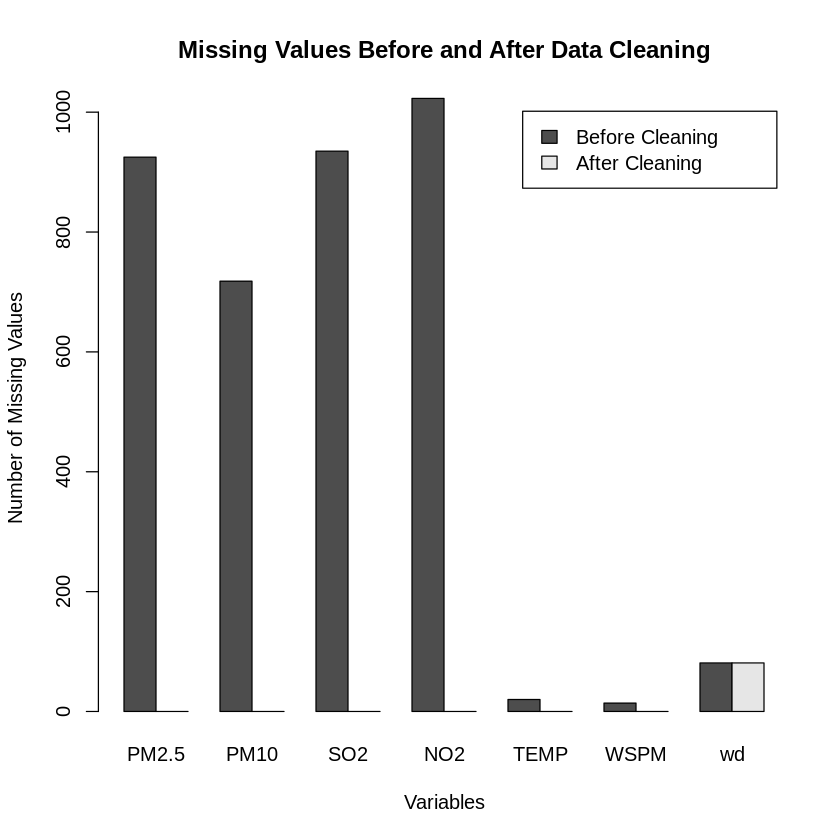

In [14]:
graph_values <- rbind(
  comparison_table$Missing_Before,
  comparison_table$Missing_After
)

barplot(
  graph_values,
  beside = TRUE,
  names.arg = comparison_table$Variable,
  main = "Missing Values Before and After Data Cleaning",
  xlab = "Variables",
  ylab = "Number of Missing Values",
  legend.text = c(
    "Before Cleaning",
    "After Cleaning"
  )
)

In [15]:
#Save visualization as PNG
png(
  "/content/missing_values_chart.png",
  width = 1000,
  height = 700
)

barplot(
  graph_values,
  beside = TRUE,
  names.arg = comparison_table$Variable,
  main = "Missing Values Before and After Data Cleaning",
  xlab = "Variables",
  ylab = "Number of Missing Values",
  legend.text = c(
    "Before Cleaning",
    "After Cleaning"
  )
)

dev.off()

cat("Graph saved as missing_values_chart.png")

agg_record_99d743f6510 
                     2

Graph saved as missing_values_chart.png

# TASK 10: Export Cleaned Dataset

In [16]:
write.csv(
  air_quality,
  "/content/cleaned_air_quality_data.csv",
  row.names = FALSE
)

cat("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.

#Interpretation

The Beijing air-quality dataset contained missing observations in several pollutant and weather variables. Missing values were first identified and summarized using a user-defined function. Numerical variables such as PM2.5, PM10, SO2, NO2, TEMP, and WSPM were treated using median imputation because the median is less sensitive to extreme values. Missing wind-direction values were replaced using the mode since wind direction is categorical. The pollution ratio was checked for NA, NaN, and infinite values, and invalid numerical results were converted to NA. Loops and reusable functions reduced repetitive code, while tryCatch() provided effective error handling. Finally, missing values before and after cleaning were compared to verify the cleaning process. The cleaned dataset was successfully exported and is now suitable for further air-quality analysis.